In [1]:
from matplotlib import pyplot as plt
import numpy as np
from astropy.io import fits
import healpy as hp
from healpy.newvisufunc import projview, newprojplot
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
import h5py
from scipy.ndimage import map_coordinates

In [2]:
vmin = np.nanpercentile(whamIntegrated, 5)
vmax = np.nanpercentile(whamIntegrated, 95)

plt.figure(figsize=(12, 6))
plt.imshow(whamIntegrated, origin='lower', vmin=vmin, vmax=vmax, cmap='inferno')
plt.colorbar(label='H-alpha intensity (R)')
plt.title('WHAM Integrated H-alpha')
plt.show()

NameError: name 'whamIntegrated' is not defined

In [3]:
import matplotlib.colors as mcolors
original_cmap = plt.get_cmap('Set1')

colors = original_cmap(np.arange(1,6,1))
Set11 = mcolors.ListedColormap(colors)

In [8]:
fn = '~/Research/DRAGONS/DRAGONS_faraday_depth_cubes/faraday_synthesis/dragons_Npeaks_8sigma.hpx.fits' 
eightsigmapeaksdat = fits.getdata(fn)
eightsigmapeakdshdr = fits.getheader(fn)
fn1 = '~/Research/DRAGONS/DRAGONS_faraday_depth_cubes/faraday_synthesis/dragons_Npeaks_8sigma.car.fits' 
eightsigmapeakscardat = fits.getdata(fn1)
eightsigmapeakscarhdr = fits.getheader(fn1)

FileNotFoundError: [Errno 2] No such file or directory: '/home/justin/Research/DRAGONS/DRAGONS_faraday_depth_cubes/faraday_synthesis/dragons_Npeaks_8sigma.hpx.fits'

NameError: name 'eightsigmapeakscardat' is not defined

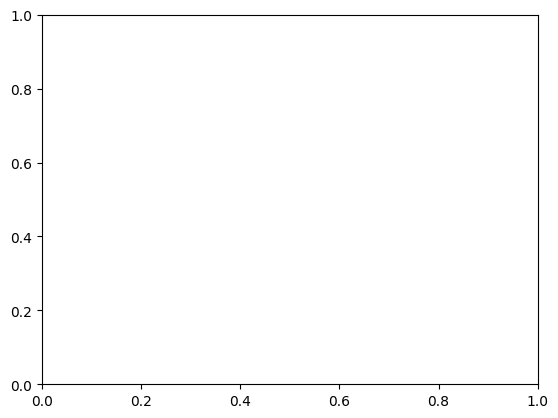

In [5]:
fig, ax = plt.subplots(1,1) 
im = ax.imshow(eightsigmapeakscardat, 
               cmap = Set11, vmin =1, vmax = 5,
               origin = 'lower'
              )
plt.colorbar(im)
ax.set_xlim(240,250)
ax.set_ylim(70,90)

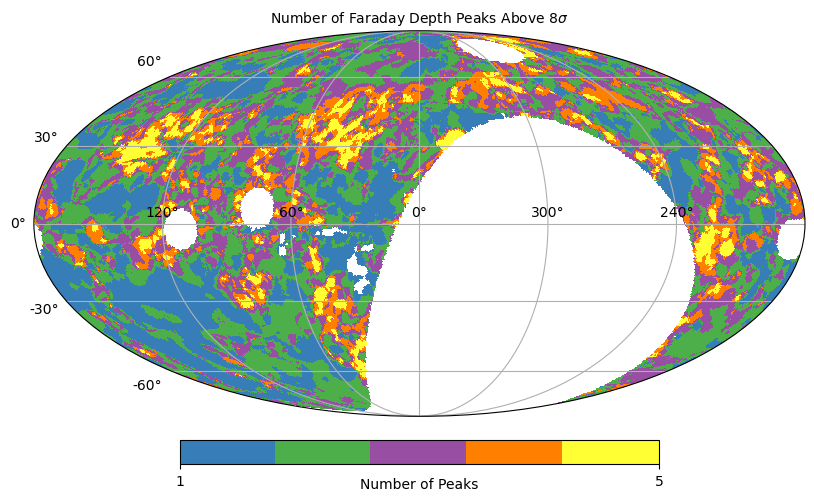

In [6]:
projview(
    eightsigmapeaksdat,
    projection_type = 'mollweide', 
    graticule = True, 
    graticule_labels=True, 
    # xlabel="Longitude", 
    # ylabel="Latitude", 
    cb_orientation = "horizontal",
    cmap = Set11,
    min = 1, 
    max = 5,
    unit = r'Number of Peaks',
    title = r'Number of Faraday Depth Peaks Above 8$\sigma$', 
    fontsize={
    "title":10,
    "xtick_label":10,
    "ytick_label":10, 
    "cbar_label":10
    }
    )

In [7]:
fn = '~/Research/DRAGONS/DRAGONS_faraday_depth_cubes/faraday_synthesis/dragons_Npeaks_8sigma.car.fits'
Npeakscardat = fits.getdata(fn)
Npeakscarhdr = fits.getheader(fn)

In [8]:
#loading dirty Faraday Depth Cube for spectra
fn = '~/Research/DRAGONS/DRAGONS_faraday_depth_cubes/faraday_synthesis/dragons_FDF_tot_dirty_Kgal.car.fits'
FDdirtydat = fits.getdata(fn)
FDdirtyhdr = fits.getheader(fn)

In [9]:
#loading clean Faraday Depth Cube for spectra from DRAGONS
fn = '~/Research/DRAGONS/DRAGONS_faraday_depth_cubes/faraday_synthesis/dragons_FDF_clean_tot_Kgal.car.fits'
FDcleandat = fits.getdata(fn) 
FDcleanhdr = fits.getheader(fn)

In [10]:
wcs = WCS(FDcleanhdr)
wcs

WCS Keywords

Number of WCS axes: 3
CTYPE : 'GLON-CAR' 'GLAT-CAR' 'FDEP'
CUNIT : 'deg' 'deg' 'rad / m2'
CRVAL : 0.0 0.0 0.0
CRPIX : 360.5 180.5 401.0
PC1_1 PC1_2 PC1_3  : 1.0 0.0 0.0
PC2_1 PC2_2 PC2_3  : 0.0 1.0 0.0
PC3_1 PC3_2 PC3_3  : 0.0 0.0 1.0
CDELT : -0.5 0.5 0.5
NAXIS : 720  360  801

In [11]:
FDcleanhdr

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    3 / number of array dimensions                     
NAXIS1  =                  720                                                  
NAXIS2  =                  360                                                  
NAXIS3  =                  801                                                  
COORDSYS= 'Galactic '          / Ecliptic, Galactic or Celestial (equatorial)   
CRPIX2  =                180.5                                                  
CDELT2  =                  0.5                                                  
CUNIT2  = 'deg     '                                                            
BUNIT   = 'K/RMSF  '                                                            
CTYPE2  = 'GLAT-CAR'                                                            
CRVAL2  =                   

In [12]:
Npeakscarhdr

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  720                                                  
NAXIS2  =                  360                                                  
COORDSYS= 'galactic'           / Ecliptic, Galactic or Celestial (equatorial)   
CRPIX2  =                180.5                                                  
CDELT2  =                  0.5                                                  
CUNIT2  = 'deg     '                                                            
BUNIT   = 'NUMBER  '                                                            
CTYPE2  = 'GLAT-CAR'                                                            
CRVAL2  =                    0                                                  
CTYPE1  = 'GLON-CAR'        

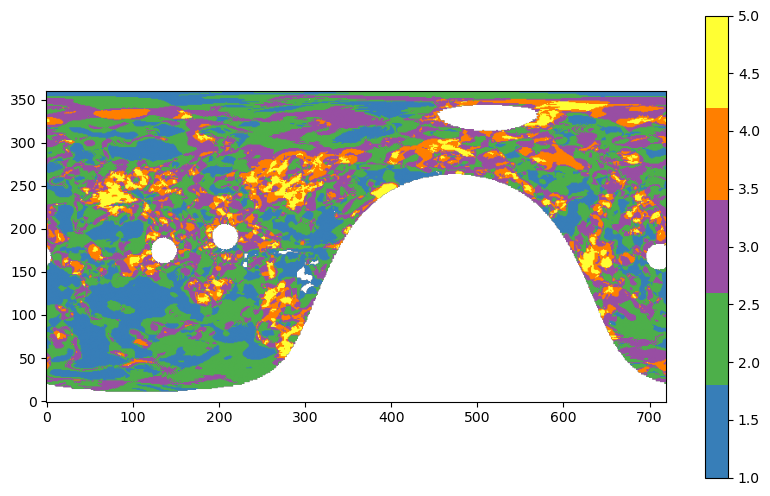

In [13]:
figsize = (10, 6)
fig, ax = plt.subplots(1,1, figsize = figsize)#, subplot_kw={'projection'})#: wcs.celestial})
im0 = ax.imshow(Npeakscardat, origin='lower', cmap = Set11, vmin=1, vmax=5)

plt.colorbar(im0)
plt.show()

In [14]:
mask = (Npeakscardat == 0)

y_indices, x_indices = np.where(mask)

zero_comp_pix_coord = list(zip(x_indices, y_indices)) 

print(len(zero_comp_pix_coord), zero_comp_pix_coord[:5])

0 []


# Finding lines of sight with given faraday complexity, as well as the regions with this complexity. Region here, defined as an area greater than or equal to 59 square pixels. Based on the beam area of the 15 m telescope at DRAO

## faraday complexity: 1

In [15]:
wcs = WCS(Npeakscarhdr)

In [16]:
mask = (0 < Npeakscardat) & (Npeakscardat < 2)

yIndices, xIndices = np.where(mask)

oneCompPixCoord = np.column_stack((xIndices, yIndices)) 

print(len(oneCompPixCoord), oneCompPixCoord[:5]) 

37695 [[113  12]
 [114  12]
 [115  12]
 [116  12]
 [133  12]]


In [17]:
wcs = WCS(Npeakscarhdr, naxis =2)

beamLimit = 7.2 #pixels 
group = list(range(len(oneCompPixCoord)))
newLoS = []
while group: 
    currentIndex = group.pop(0)
    currentRegion = [tuple(oneCompPixCoord[currentIndex])]
    queue = [oneCompPixCoord[currentIndex]] 

    while queue: 
        point = queue.pop(0)

        if not group: 
            break 

        groupCoords = oneCompPixCoord[group] 
        distances = np.linalg.norm(groupCoords - point, axis=1)

        closeIndices = np.where(distances <= beamLimit)[0]

        for idx in sorted(closeIndices, reverse=True):
            actualIdx = group.pop(idx)
            pixel = tuple(oneCompPixCoord[actualIdx])
            currentRegion.append(pixel)
            queue.append(oneCompPixCoord[actualIdx])
        
        newLoS.append(currentRegion)

minimumPixArea = 59 
resolvedRegions = [r for r in newLoS if len(r) >= minimumPixArea]

print(f"Number of regions: {len(resolvedRegions)}, distinct lines of sight: {len(newLoS)}")

Number of regions: 36726, distinct lines of sight: 37684


In [18]:
#try doing the same thing with centroids instead 
compOneLoSCentroids = np.zeros((len(newLoS), 2), dtype=np.float32)

for i, region in enumerate(newLoS):
    regionArray = np.array(region,dtype=np.int32)
    skyCoords = wcs.pixel_to_world(regionArray[:, 0], regionArray[:,1])
    galCoords = skyCoords.galactic 
    compOneLoSCentroids[i, 0] = np.mean(galCoords.l.deg)
    compOneLoSCentroids[i, 1] = np.mean(galCoords.b.deg)

print(f"Centroids shape: {compOneLoSCentroids.shape}")
print(f"Example centroid: {compOneLoSCentroids[0]}")

Centroids shape: (37684, 2)
Example centroid: [111.15854 -82.05285]


## complexity = 2

In [20]:
mask = (1 < Npeakscardat) & (Npeakscardat < 3)

yIndices, xIndices = np.where(mask)

twoCompPixCoord = np.column_stack((xIndices, yIndices)) 

print(len(twoCompPixCoord), twoCompPixCoord[:5]) 

60185 [[69 12]
 [70 12]
 [71 12]
 [72 12]
 [73 12]]


In [23]:
wcs = WCS(Npeakscarhdr, naxis =2)

beamLimit = 7.2 #pixels 
group = list(range(len(twoCompPixCoord)))
compTwoNewLoS = []
while group: 
    currentIndex = group.pop(0)
    currentRegion = [tuple(twoCompPixCoord[currentIndex])]
    queue = [twoCompPixCoord[currentIndex]] 

    while queue: 
        point = queue.pop(0)

        if not group: 
            break 

        groupCoords = twoCompPixCoord[group] 
        distances = np.linalg.norm(groupCoords - point, axis=1)

        closeIndices = np.where(distances <= beamLimit)[0]

        for idx in sorted(closeIndices, reverse=True):
            actualIdx = group.pop(idx)
            pixel = tuple(twoCompPixCoord[actualIdx])
            currentRegion.append(pixel)
            queue.append(twoCompPixCoord[actualIdx])
        
        compTwoNewLoS.append(currentRegion)

minimumPixArea = 59 
compTwoResolvedRegions = [r for r in compTwoNewLoS if len(r) >= minimumPixArea]

print(f"Number of regions: {len(compTwoResolvedRegions)}, distinct lines of sight: {len(compTwoNewLoS)}")

Number of regions: 59972, distinct lines of sight: 60153


In [29]:
print(f"compTwoNewLoS length: {len(compTwoNewLoS)}")
print(f"Region 0 length: {len(compTwoNewLoS[0])}")
print(f"Region 1 length: {len(compTwoNewLoS[1])}")
print(f"Same object: {compTwoNewLoS[0] is compTwoNewLoS[1]}")

compTwoNewLoS length: 60153
Region 0 length: 59040
Region 1 length: 59040
Same object: True


In [28]:
print(f"Number of LoS: {len(compTwoNewLoS)}")
print(f"Region 0 length: {len(compTwoNewLoS[0])}")
print(f"Region 0 first pixel: {compTwoNewLoS[0][0]}")

Number of LoS: 60153
Region 0 length: 59040
Region 0 first pixel: (np.int64(69), np.int64(12))


In [27]:
#try doing the same thing with centroids instead 
wcs = WCS(Npeakscarhdr, naxis=2)
compTwoLoSCentroids = np.zeros((len(compTwoNewLoS), 2), dtype=np.float32)

for i, region in enumerate(compTwoNewLoS):
    regionArray = np.array(region,dtype=np.int32)
    skyCoords = wcs.pixel_to_world(regionArray[:, 0], regionArray[:,1])
    galCoords = skyCoords.galactic 
    compTwoLoSCentroids[i, 0] = np.mean(galCoords.l.deg)
    compTwoLoSCentroids[i, 1] = np.mean(galCoords.b.deg)

print(f"Centroids shape: {compTwoLoSCentroids.shape}")
print(f"Example centroid: {compTwoLoSCentroids[0]}")

KeyboardInterrupt: 

In [ ]:
chunkSize = 1000

with h5py.File("compTwoGalCoords.h5", "w") as f: 
    for regionIdx, region in enumerate(compTwoResolvedRegions):
        regionArray = np.array(region, dtype=np.int32)
        lChunks=[]
        bChunks=[]
        for i in range(0, len(regionArray), chunkSize):
            chunk = regionArray[i:i + chunkSize]
            skyCoords = wcs.pixel_to_world(chunk[:,0], chunk[:,1])
            galCoords = skyCoords.galactic
            lChunks.append(galCoords.l.deg.astype(np.float32))
            bChunks.append(galCoords.b.deg.astype(np.float32))
            del skyCoords, galCoords, chunk 
        galArray = np.column_stack((np.concatenate(lChunks), np.concatenate(bChunks)))
        f.create_dataset(f"region{regionIdx}", data=galArray)
        del regionArray, galArray, lChunks, bChunks
print("Done. Access later with h5py.")

In [ ]:
#reserved for h5py access
#
#
#
#
#

## complexity = 3

In [ ]:
mask = (2 < Npeakscardat) & (Npeakscardat < 4)

yIndices, xIndices = np.where(mask)

threeCompPixCoord = np.column_stack((xIndices, yIndices)) 

print(len(threeCompPixCoord), threeCompPixCoord[:5]) 

In [ ]:
wcs = WCS(Npeakscarhdr, naxis =2)

beamLimit = 7.2 #pixels 
group = list(range(len(threeCompPixCoord)))
compThreeNewLoS = []
while group: 
    currentIndex = group.pop(0)
    currentRegion = [tuple(threeCompPixCoord[currentIndex])]
    queue = [threeCompPixCoord[currentIndex]] 

    while queue: 
        point = queue.pop(0)

        if not group: 
            break 

        groupCoords = threeCompPixCoord[group] 
        distances = np.linalg.norm(groupCoords - point, axis=1)

        closeIndices = np.where(distances <= beamLimit)[0]

        for idx in sorted(closeIndices, reverse=True):
            actualIdx = group.pop(idx)
            pixel = tuple(threeCompPixCoord[actualIdx])
            currentRegion.append(pixel)
            queue.append(threeCompPixCoord[actualIdx])
        
        compThreeNewLoS.append(currentRegion)

minimumPixArea = 59 
compThreeResolvedRegions = [r for r in compThreeNewLoS if len(r) >= minimumPixArea]

print(f"Number of regions: {len(compThreeResolvedRegions)}, distinct lines of sight: {len(compThreeNewLoS)}")

In [ ]:
#try doing the same thing with centroids instead 
compThreeLoSCentroids = np.zeros((len(compThreeNewLoS), 2), dtype=np.float32)

for i, region in enumerate(compThreeNewLoS):
    regionArray = np.array(region,dtype=np.int32)
    skyCoords = wcs.pixel_to_world(regionArray[:, 0], regionArray[:,1])
    galCoords = skyCoords.galactic 
    compThreeLoSCentroids[i, 0] = np.mean(galCoords.l.deg)
    compThreeLoSCentroids[i, 1] = np.mean(galCoords.b.deg)

print(f"Centroids shape: {compThreeLoSCentroids.shape}")
print(f"Example centroid: {compThreeLoSCentroids[0]}")

## complexity= 4

In [ ]:
mask = (3 < Npeakscardat) & (Npeakscardat < 5)

yIndices, xIndices = np.where(mask)

fourCompPixCoord = np.column_stack((xIndices, yIndices)) 

print(len(fourCompPixCoord), fourCompPixCoord[:5]) 

In [ ]:
wcs = WCS(Npeakscarhdr, naxis =2)

beamLimit = 7.2 #pixels 
group = list(range(len(fourCompPixCoord)))
compFourNewLoS = []
while group: 
    currentIndex = group.pop(0)
    currentRegion = [tuple(fourCompPixCoord[currentIndex])]
    queue = [fourCompPixCoord[currentIndex]] 

    while queue: 
        point = queue.pop(0)

        if not group: 
            break 

        groupCoords = fourCompPixCoord[group] 
        distances = np.linalg.norm(groupCoords - point, axis=1)

        closeIndices = np.where(distances <= beamLimit)[0]

        for idx in sorted(closeIndices, reverse=True):
            actualIdx = group.pop(idx)
            pixel = tuple(fourCompPixCoord[actualIdx])
            currentRegion.append(pixel)
            queue.append(fourCompPixCoord[actualIdx])
        
        compFourNewLoS.append(currentRegion)

minimumPixArea = 59 
compFourResolvedRegions = [r for r in compFourNewLoS if len(r) >= minimumPixArea]

print(f"Number of regions: {len(compFourResolvedRegions)}, distinct lines of sight: {len(compFourNewLoS)}")

In [ ]:
#try doing the same thing with centroids instead 
compFourLoSCentroids = np.zeros((len(compFourNewLoS), 2), dtype=np.float32)

for i, region in enumerate(compFourNewLoS):
    regionArray = np.array(region,dtype=np.int32)
    skyCoords = wcs.pixel_to_world(regionArray[:, 0], regionArray[:,1])
    galCoords = skyCoords.galactic 
    compFourLoSCentroids[i, 0] = np.mean(galCoords.l.deg)
    compFourLoSCentroids[i, 1] = np.mean(galCoords.b.deg)

print(f"Centroids shape: {compFourLoSCentroids.shape}")
print(f"Example centroid: {compFourLoSCentroids[0]}")

In [ ]:
wcs = WCS(Npeakscarhdr)
compFourLoSGalCoords = []
for region in compFourNewLoS:
    regionArray = np.array(region)
    skyCoords = wcs.pixel_to_world(regionArray[:, 0], regionArray[:, 1])
    galCoords = skyCoords.galactic
    galArray = np.column_stack((galCoords.l.deg, galCoords.b.deg))
    compFourLoSGalCoords.append(galArray)

print(f"Number of LoS: {len(compFourLoSGalCoords)}")
print(f"Example LoS galactic coords \n{compFourLoSGalCoords[0]},\n{compFourLoSGalCoords[17]}")

## complexity = 5

In [ ]:
mask = (4 < Npeakscardat) & (Npeakscardat < 6)

yIndices, xIndices = np.where(mask)

fiveCompPixCoord = np.column_stack((xIndices, yIndices)) 

print(len(fiveCompPixCoord), fiveCompPixCoord[:5]) 

In [ ]:
wcs = WCS(Npeakscarhdr, naxis =2)

beamLimit = 7.2 #pixels 
group = list(range(len(fiveCompPixCoord)))
compFiveNewLoS = []
while group: 
    currentIndex = group.pop(0)
    currentRegion = [tuple(fiveCompPixCoord[currentIndex])]
    queue = [fiveCompPixCoord[currentIndex]] 

    while queue: 
        point = queue.pop(0)

        if not group: 
            break 

        groupCoords = fiveCompPixCoord[group] 
        distances = np.linalg.norm(groupCoords - point, axis=1)

        closeIndices = np.where(distances <= beamLimit)[0]

        for idx in sorted(closeIndices, reverse=True):
            actualIdx = group.pop(idx)
            pixel = tuple(fiveCompPixCoord[actualIdx])
            currentRegion.append(pixel)
            queue.append(fiveCompPixCoord[actualIdx])
        
        compFiveNewLoS.append(currentRegion)

minimumPixArea = 59 
compFiveResolvedRegions = [r for r in compFiveNewLoS if len(r) >= minimumPixArea]

print(f"Number of regions: {len(compFiveResolvedRegions)}, distinct lines of sight: {len(compFiveNewLoS)}")

In [ ]:
#try doing the same thing with centroids instead 
compFiveLoSCentroids = np.zeros((len(compFiveNewLoS), 2), dtype=np.float32)

for i, region in enumerate(compFiveNewLoS):
    regionArray = np.array(region,dtype=np.int32)
    skyCoords = wcs.pixel_to_world(regionArray[:, 0], regionArray[:,1])
    galCoords = skyCoords.galactic 
    compFiveLoSCentroids[i, 0] = np.mean(galCoords.l.deg)
    compFiveLoSCentroids[i, 1] = np.mean(galCoords.b.deg)

print(f"Centroids shape: {compFiveLoSCentroids.shape}")
print(f"Example centroid: {compFiveLoSCentroids[0]}")

In [ ]:
wcs = WCS(Npeakscarhdr)
compFiveLoSGalCoords = []
for region in compFiveNewLoS:
    regionArray = np.array(region)
    skyCoords = wcs.pixel_to_world(regionArray[:, 0], regionArray[:, 1])
    galCoords = skyCoords.galactic
    galArray = np.column_stack((galCoords.l.deg, galCoords.b.deg))
    compFiveLoSGalCoords.append(galArray)

print(f"Number of LoS: {len(compFiveLoSGalCoords)}")
print(f"Example LoS galactic coords \n{compFiveLoSGalCoords[0]},\n{compFiveLoSGalCoords[17]}")

## complexity = 6

In [ ]:
mask = (5 < Npeakscardat) & (Npeakscardat < 7)
yIndices, xIndices = np.where(mask)

sixCompPixCoord = np.column_stack((xIndices, yIndices)) 

print(len(sixCompPixCoord), sixCompPixCoord[:5]) 

In [ ]:
wcs = WCS(Npeakscarhdr, naxis =2)

beamLimit = 7.2 #pixels 
group = list(range(len(sixCompPixCoord)))
compSixNewLoS = []
while group: 
    currentIndex = group.pop(0)
    currentRegion = [tuple(sixCompPixCoord[currentIndex])]
    queue = [sixCompPixCoord[currentIndex]] 

    while queue: 
        point = queue.pop(0)

        if not group: 
            break 

        groupCoords = sixCompPixCoord[group] 
        distances = np.linalg.norm(groupCoords - point, axis=1)

        closeIndices = np.where(distances <= beamLimit)[0]

        for idx in sorted(closeIndices, reverse=True):
            actualIdx = group.pop(idx)
            pixel = tuple(sixCompPixCoord[actualIdx])
            currentRegion.append(pixel)
            queue.append(sixCompPixCoord[actualIdx])
        
        compSixNewLoS.append(currentRegion)

minimumPixArea = 59 
compSixResolvedRegions = [r for r in compSixNewLoS if len(r) >= minimumPixArea]

print(f"Number of regions: {len(compSixResolvedRegions)}, distinct lines of sight: {len(compSixNewLoS)}")

In [ ]:
#try doing the same thing with centroids instead 
compSixLoSCentroids = np.zeros((len(compSixNewLoS), 2), dtype=np.float32)

for i, region in enumerate(compSixNewLoS):
    regionArray = np.array(region,dtype=np.int32)
    skyCoords = wcs.pixel_to_world(regionArray[:, 0], regionArray[:,1])
    galCoords = skyCoords.galactic 
    compSixLoSCentroids[i, 0] = np.mean(galCoords.l.deg)
    compSixLoSCentroids[i, 1] = np.mean(galCoords.b.deg)

print(f"Centroids shape: {compSixLoSCentroids.shape}")
print(f"Example centroid: {compSixLoSCentroids[0]}")

In [ ]:
wcs = WCS(Npeakscarhdr)
compSixLoSGalCoords = []
for region in compSixNewLoS:
    regionArray = np.array(region)
    skyCoords = wcs.pixel_to_world(regionArray[:, 0], regionArray[:, 1])
    galCoords = skyCoords.galactic
    galArray = np.column_stack((galCoords.l.deg, galCoords.b.deg))
    compSixLoSGalCoords.append(galArray)

print(f"Number of LoS: {len(compSixLoSGalCoords)}")
print(f"Example LoS galactic coords \n{compSixLoSGalCoords[0]},\n{compSixLoSGalCoords[17]}")

## complexity = 7 

In [ ]:
mask = (6 < Npeakscardat) & (Npeakscardat < 8)

yIndices, xIndices = np.where(mask)

sevenCompPixCoord = np.column_stack((xIndices, yIndices)) 

print(len(sevenCompPixCoord), sevenCompPixCoord[:5]) 

In [ ]:
wcs = WCS(Npeakscarhdr, naxis =2)

beamLimit = 7.2 #pixels 
group = list(range(len(sevenCompPixCoord)))
compSevenNewLoS = []
while group: 
    currentIndex = group.pop(0)
    currentRegion = [tuple(sevenCompPixCoord[currentIndex])]
    queue = [sevenCompPixCoord[currentIndex]] 

    while queue: 
        point = queue.pop(0)

        if not group: 
            break 

        groupCoords = sevenCompPixCoord[group] 
        distances = np.linalg.norm(groupCoords - point, axis=1)

        closeIndices = np.where(distances <= beamLimit)[0]

        for idx in sorted(closeIndices, reverse=True):
            actualIdx = group.pop(idx)
            pixel = tuple(sevenCompPixCoord[actualIdx])
            currentRegion.append(pixel)
            queue.append(sevenCompPixCoord[actualIdx])
        
        compSevenNewLoS.append(currentRegion)

minimumPixArea = 59 
compSevenResolvedRegions = [r for r in compSevenNewLoS if len(r) >= minimumPixArea]

print(f"Number of regions: {len(compSevenResolvedRegions)}, distinct lines of sight: {len(compSevenNewLoS)}")

In [ ]:
#try doing the same thing with centroids instead 
compSevenLoSCentroids = np.zeros((len(compSevenNewLoS), 2), dtype=np.float32)

for i, region in enumerate(compSevenNewLoS):
    regionArray = np.array(region,dtype=np.int32)
    skyCoords = wcs.pixel_to_world(regionArray[:, 0], regionArray[:,1])
    galCoords = skyCoords.galactic 
    compSevenLoSCentroids[i, 0] = np.mean(galCoords.l.deg)
    compSevenLoSCentroids[i, 1] = np.mean(galCoords.b.deg)

print(f"Centroids shape: {compSevenLoSCentroids.shape}")
print(f"Example centroid: {compSevenLoSCentroids[0]}")

In [ ]:
wcs = WCS(Npeakscarhdr)
compSevenLoSGalCoords = []
for region in compSevenNewLoS:
    regionArray = np.array(region)
    skyCoords = wcs.pixel_to_world(regionArray[:, 0], regionArray[:, 1])
    galCoords = skyCoords.galactic
    galArray = np.column_stack((galCoords.l.deg, galCoords.b.deg))
    compSevenLoSGalCoords.append(galArray)

print(f"Number of LoS: {len(compSevenLoSGalCoords)}")
print(f"Example LoS galactic coords \n{compSevenLoSGalCoords[0]},\n{compSevenLoSGalCoords[17]}")

## complexity = 8

In [ ]:
mask = (7 < Npeakscardat) & (Npeakscardat < 9)

yIndices, xIndices = np.where(mask)

eightCompPixCoord = np.column_stack((xIndices, yIndices)) 

print(len(eightCompPixCoord), eightCompPixCoord[:5]) 

In [ ]:
wcs = WCS(Npeakscarhdr, naxis =2)

beamLimit = 7.2 #pixels 
group = list(range(len(eightCompPixCoord)))
compEightNewLoS = []
while group: 
    currentIndex = group.pop(0)
    currentRegion = [tuple(eightCompPixCoord[currentIndex])]
    queue = [eightCompPixCoord[currentIndex]] 

    while queue: 
        point = queue.pop(0)

        if not group: 
            break 

        groupCoords = eightCompPixCoord[group] 
        distances = np.linalg.norm(groupCoords - point, axis=1)

        closeIndices = np.where(distances <= beamLimit)[0]

        for idx in sorted(closeIndices, reverse=True):
            actualIdx = group.pop(idx)
            pixel = tuple(eightCompPixCoord[actualIdx])
            currentRegion.append(pixel)
            queue.append(eightCompPixCoord[actualIdx])
        
        compEightNewLoS.append(currentRegion)

minimumPixArea = 59 
compEightResolvedRegions = [r for r in compEightNewLoS if len(r) >= minimumPixArea]

print(f"Number of regions: {len(compEightResolvedRegions)}, distinct lines of sight: {len(compEightNewLoS)}")

In [ ]:
#try doing the same thing with centroids instead 
compEightLoSCentroids = np.zeros((len(compEightNewLoS), 2), dtype=np.float32)

for i, region in enumerate(compEightNewLoS):
    regionArray = np.array(region,dtype=np.int32)
    skyCoords = wcs.pixel_to_world(regionArray[:, 0], regionArray[:,1])
    galCoords = skyCoords.galactic 
    compEightLoSCentroids[i, 0] = np.mean(galCoords.l.deg)
    compEightLoSCentroids[i, 1] = np.mean(galCoords.b.deg)

print(f"Centroids shape: {compEightLoSCentroids.shape}")
print(f"Example centroid: {compEightLoSCentroids[0]}")

In [ ]:
compEightLoSGalCoords = []
for region in compEightNewLoS:
    regionArray = np.array(region)
    skyCoords = wcs.pixel_to_world(regionArray[:, 0], regionArray[:, 1])
    galCoords = skyCoords.galactic
    galArray = np.column_stack((galCoords.l.deg, galCoords.b.deg))
    compEightLoSGalCoords.append(galArray)

print(f"Number of LoS: {len(compEightLoSGalCoords)}")
print(f"Example LoS galactic coords \n{compEightLoSGalCoords[0]},\n{compEightLoSGalCoords[17]}")

In [83]:
totalPixels = sum(len(pixelGalCoords[name]) for name in ['two', 'three', 'four', 'five', 'six', 'seven', 'eight'])
complexPixels = sum(len(pixelGalCoords[name]) for name in ['three', 'four', 'five', 'six', 'seven', 'eight'])
print(f"Percentage complex: {complexPixels/totalPixels * 100:.2f}%")

Percentage complex: 54.27%


# Plotting

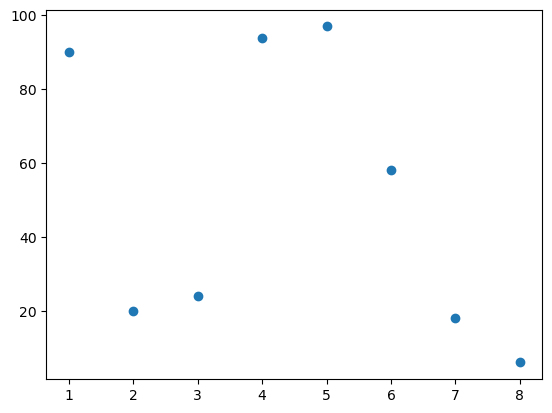

In [85]:
y = np.array([len(compOneNewLoS), len(compTwoNewLoS), len(compThreeNewLoS), len(compFourNewLoS), len(compFiveNewLoS), len(compSixNewLoS), len(compSevenNewLoS), len(compEightNewLoS)])
x = np.array([1, 2, 3, 4, 5, 6 ,7 ,8])
plt.scatter(x, y)

<BarContainer object of 8 artists>

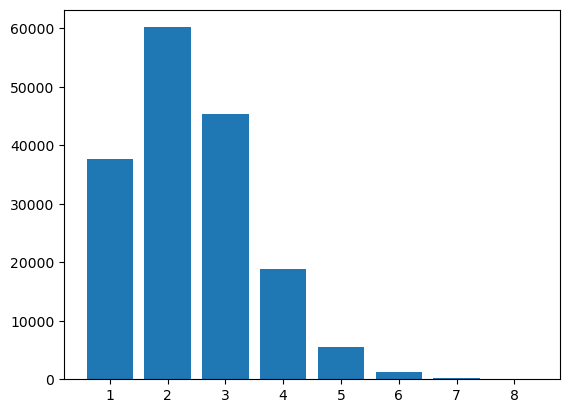

In [56]:
y = np.array([len(newLoS), len(compTwoNewLoS), len(compThreeNewLoS), len(compFourNewLoS), len(compFiveNewLoS), len(compSixNewLoS), len(compSevenNewLoS), len(compEightNewLoS)])
x = np.array([1, 2, 3, 4, 5, 6 ,7 ,8])
plt.bar(x, y)

# working with WHAM

In [57]:
fn = '/home/justin/Research/WHAM/wham-ss-DR1-v161116-170912-grid.fits'
whamdat = fits.getdata(fn)
whamhdr = fits.getheader(fn)

In [274]:
whamhdr

SIMPLE  =                    T /  Written by IDL:  Tue Sep 12 13:28:51 2017     
BITPIX  =                  -32 / Real*4 (floating point)                        
NAXIS   =                    3 /                                                
NAXIS1  =                 1440 /                                                
NAXIS2  =                  720 /                                                
NAXIS3  =                  162 /                                                
EXTEND  =                    T / Extensions may be present                      
DATE    = '2017-09-12'         /                                                
TAG     = 'DR1     '           / General release tag                            
VERSION = '161116  '           / Generated from wham-ss-161116.sav              
OBJECT  = 'WHAM Sky Survey - Release DR1 (161116)' /                            
RESTWAV =          6.56300E-07 / Rest wavelength of H-alpha [m]                 
BSCALE  =              1.000

In [58]:
#putting velo axis in km/s 
nVel = whamhdr['NAXIS3']
crval3 = whamhdr['CRVAL3']
crpix3 = whamhdr['CRPIX3']
cdelt3 = whamhdr['CDELT3']

velAxis = (crval3 + (np.arange(nVel) - (crpix3 -1)) * cdelt3) / 1000
print(f"Velocity range: {velAxis[0]:.1f} to {velAxis[-1]:.1f} km/s")

Velocity range: -169.1 to 157.3 km/s


In [249]:

velMask = (velAxis >= -169.1) & (velAxis <= 157.3)
velMask.sum()

np.int64(160)

In [250]:
whamIntegrated = np.nansum(whamdat[velMask, :, :] * abs(cdelt3), axis=0) / 1000


In [251]:
print(f"NaN count: {np.sum(np.isnan(whamdat))}")
print(f"Zero count: {np.sum(whamdat == 0)}")
print(f"Data range: {np.nanmin(whamdat):.4f} to {np.nanmax(whamdat):.4f}")
print(f"Integrated map range: {np.nanmin(whamIntegrated):.4f} to {np.nanmax(whamIntegrated):.4f}")

NaN count: 65383544
Zero count: 0
Data range: -0.0994 to 77.8963
Integrated map range: -1.6279 to 4421.7070


In [252]:
print(f"Channels selected: {velMask.sum()}")
print(f"Velocity range used: {velAxis[velMask][0]:.1f} to {velAxis[velMask][-1]:.1f} km/s")

Channels selected: 160
Velocity range used: -167.1 to 155.3 km/s


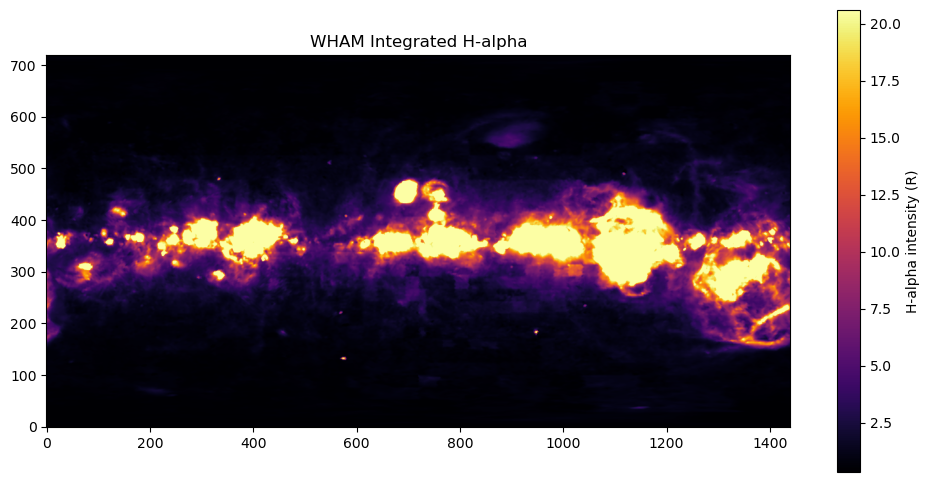

In [253]:
vmin = np.nanpercentile(whamIntegrated, 5)
vmax = np.nanpercentile(whamIntegrated, 95)

plt.figure(figsize=(12, 6))
plt.imshow(whamIntegrated, origin='lower', vmin=vmin, vmax=vmax, cmap='inferno')
plt.colorbar(label='H-alpha intensity (R)')
plt.title('WHAM Integrated H-alpha')
plt.show()

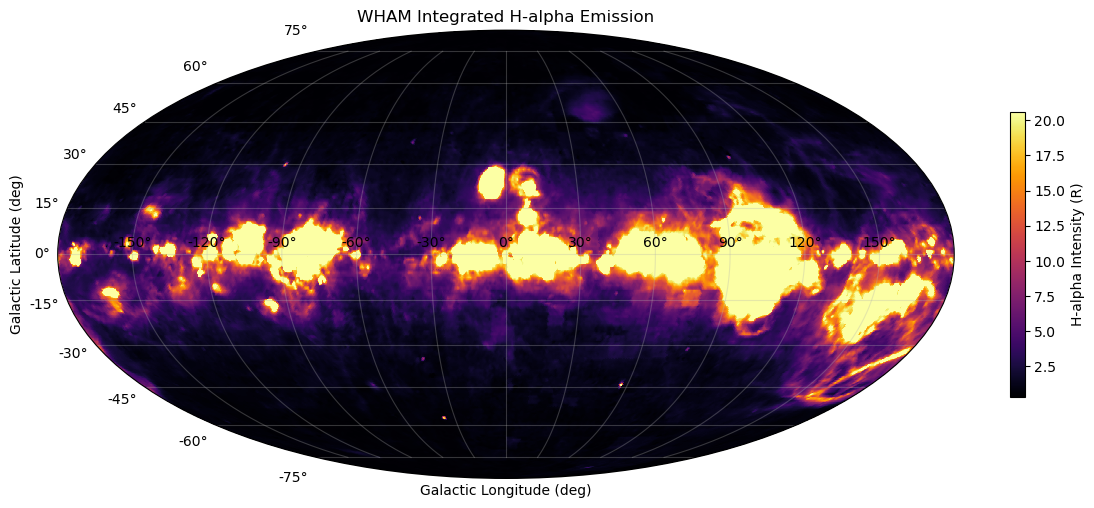

In [412]:
lon = np.linspace(-180,180, whamIntegrated.shape[1])
lat = np.linspace(-90, 90, whamIntegrated.shape[0])
lonGrid, latGrid = np.meshgrid(np.deg2rad(lon), np.deg2rad(lat))

vmin = np.nanpercentile(whamIntegrated, 5)
vmax = np.nanpercentile(whamIntegrated, 95)

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='mollweide')
img = ax.pcolormesh(lonGrid, latGrid, whamIntegrated, cmap='inferno', vmin=vmin, vmax=vmax)
plt.colorbar(img, ax=ax, label='H-alpha Intensity (R)', shrink=0.5)
ax.set_xlabel('Galactic Longitude (deg)')
ax.set_ylabel('Galactic Latitude (deg)')
ax.grid(True, alpha=0.3)
plt.title('WHAM Integrated H-alpha Emission')
plt.tight_layout()
plt.show()

# stats with WHAM and DRAGONS looking for corellation between h-alpha and faraday complexity 

In [413]:
#mean h-alpha intensity in LoS with complexity 8 
whamWCS = WCS(whamhdr, naxis =2) 

allCoords = np.vstack(compEightLoSCentroids) 

xPix, yPix = whamWCS.world_to_pixel_values(allCoords[:,0], allCoords[:,1])

compEightWhamSampled = map_coordinates(whamIntegrated, [yPix, xPix], order=1, mode='nearest')

print(f"Sampled {len(compEightWhamSampled)} LoS")
print(f"H-alpha intensity range: {compEightWhamSampled.min():.2f} to {compEightWhamSampled.max():.2f}")
print(f"Mean H-alpha intensity: {compEightWhamSampled.mean():.2f}")

Sampled 18 LoS
H-alpha intensity range: 1.04 to 3.86
Mean H-alpha intensity: 2.65


In [414]:
#mean h-alpha intensity in LoS with complexity 7
whamWCS = WCS(whamhdr, naxis =2) 

allCoords = np.vstack(compSevenLoSCentroids) 

xPix, yPix = whamWCS.world_to_pixel_values(allCoords[:,0], allCoords[:,1])

compSevenWhamSampled = map_coordinates(whamIntegrated, [yPix, xPix], order=1, mode='nearest')

print(f"Sampled {len(compSevenWhamSampled)} LoS")
print(f"H-alpha intensity range: {compSevenWhamSampled.min():.2f} to {compSevenWhamSampled.max():.2f}")
print(f"Mean H-alpha intensity: {compSevenWhamSampled.mean():.2f}")

Sampled 241 LoS
H-alpha intensity range: 0.38 to 10.93
Mean H-alpha intensity: 2.48


In [415]:
#mean h-alpha intensity in LoS with complexity 6 
whamWCS = WCS(whamhdr, naxis =2) 

allCoords = np.vstack(compSixLoSCentroids) 

xPix, yPix = whamWCS.world_to_pixel_values(allCoords[:,0], allCoords[:,1])

compSixWhamSampled = map_coordinates(whamIntegrated, [yPix, xPix], order=1, mode='nearest')

print(f"Sampled {len(compSixWhamSampled)} LoS")
print(f"H-alpha intensity range: {compSixWhamSampled.min():.2f} to {compSixWhamSampled.max():.2f}")
print(f"Mean H-alpha intensity: {compSixWhamSampled.mean():.2f}")

Sampled 1217 LoS
H-alpha intensity range: -0.80 to 153.28
Mean H-alpha intensity: 3.32


In [416]:
#mean h-alpha intensity in LoS with complexity 5
whamWCS = WCS(whamhdr, naxis =2) 

allCoords = np.vstack(compFiveLoSCentroids) 

xPix, yPix = whamWCS.world_to_pixel_values(allCoords[:,0], allCoords[:,1])

compFiveWhamSampled = map_coordinates(whamIntegrated, [yPix, xPix], order=1, mode='nearest')

print(f"Sampled {len(compFiveWhamSampled)} LoS")
print(f"H-alpha intensity range: {compFiveWhamSampled.min():.2f} to {compFiveWhamSampled.max():.2f}")
print(f"Mean H-alpha intensity: {compFiveWhamSampled.mean():.2f}")

Sampled 5593 LoS
H-alpha intensity range: 0.23 to 156.05
Mean H-alpha intensity: 4.29


In [417]:
#mean h-alpha in LoS with complexity 4
whamWCS = WCS(whamhdr, naxis =2) 

allCoords = np.vstack(compFourLoSCentroids) 

xPix, yPix = whamWCS.world_to_pixel_values(allCoords[:,0], allCoords[:,1])

compFourWhamSampled = map_coordinates(whamIntegrated, [yPix, xPix], order=1, mode='nearest')

print(f"Sampled {len(compFourWhamSampled)} LoS")
print(f"H-alpha intensity range: {compFourWhamSampled.min():.2f} to {compFourWhamSampled.max():.2f}")
print(f"Mean H-alpha intensity: {compFourWhamSampled.mean():.2f}")

Sampled 18920 LoS
H-alpha intensity range: 0.32 to 142.01
Mean H-alpha intensity: 2.48


In [418]:
#mean h-alpha in LoS with complexity 3 
whamWCS = WCS(whamhdr, naxis=2) 

allCoords = np.vstack(compThreeLoSCentroids)

xPix, yPix = whamWCS.world_to_pixel_values(allCoords[:,0], allCoords[:,1])

compThreeWhamSampled = map_coordinates(whamIntegrated, [yPix, xPix], order=1, mode ='nearest')

print(f"Sampled {len(compThreeWhamSampled)} LoS")
print(f"H-alpha intensity range: {compThreeWhamSampled.min():.2f} to {compThreeWhamSampled.max():.2f}")
print(f"Mean H-alpha intensity: {compThreeWhamSampled.mean():.2f}")

Sampled 45371 LoS
H-alpha intensity range: 0.27 to 31.67
Mean H-alpha intensity: 0.80


In [419]:
#mean h-alpha in LoS with complexity 2
whamWCS = WCS(whamhdr, naxis=2) 

allCoords = np.vstack(compTwoLoSCentroids)

xPix, yPix = whamWCS.world_to_pixel_values(allCoords[:,0], allCoords[:,1])

compTwoWhamSampled = map_coordinates(whamIntegrated, [yPix, xPix], order=1, mode ='nearest')

print(f"Sampled {len(compTwoWhamSampled)} LoS")
print(f"H-alpha intensity range: {compTwoWhamSampled.min():.2f} to {compTwoWhamSampled.max():.2f}")
print(f"Mean H-alpha intensity: {compTwoWhamSampled.mean():.2f}")

Sampled 60153 LoS
H-alpha intensity range: 0.44 to 21.58
Mean H-alpha intensity: 16.51


In [420]:
#mean h-alpha in LoS with complexity 1
whamWCS = WCS(whamhdr, naxis=2) 

allCoords = np.vstack(compOneLoSCentroids)

xPix, yPix = whamWCS.world_to_pixel_values(allCoords[:,0], allCoords[:,1])

compOneWhamSampled = map_coordinates(whamIntegrated, [yPix, xPix], order=1, mode ='nearest')

print(f"Sampled {len(compOneWhamSampled)} LoS")
print(f"H-alpha intensity range: {compOneWhamSampled.min():.2f} to {compOneWhamSampled.max():.2f}")
print(f"Mean H-alpha intensity: {compOneWhamSampled.mean():.2f}")

Sampled 37684 LoS
H-alpha intensity range: 0.28 to 89.19
Mean H-alpha intensity: 2.33


In [421]:
#mean h-alpha in LoS not displaying complexity
whamWCS = WCS(whamhdr, naxis=2) 
simpleLoSCentroids = np.concatenate((compOneLoSCentroids, compTwoLoSCentroids), axis=0)

xPix, yPix = whamWCS.world_to_pixel_values(simpleLoSCentroids[:,0], simpleLoSCentroids[:,1])

simpleWhamSampled = map_coordinates(whamIntegrated, [yPix, xPix], order=1, mode ='nearest')

print(f"Sampled {len(simpleWhamSampled)} LoS")
print(f"H-alpha intensity range: {simpleWhamSampled.min():.2f} to {simpleWhamSampled.max():.2f}")
print(f"Mean H-alpha intensity: {np.mean(simpleWhamSampled):.2f}")

Sampled 97837 LoS
H-alpha intensity range: 0.28 to 89.19
Mean H-alpha intensity: 11.05


In [422]:
#mean h-alpha in LoS displaying complexity
whamWCS = WCS(whamhdr, naxis=2)
complexLoSCentroids = np.concatenate((compEightLoSCentroids, compSevenLoSCentroids, compSixLoSCentroids, compFiveLoSCentroids, compFourLoSCentroids, compThreeLoSCentroids), axis = 0)
allCoords = np.vstack(complexLoSCentroids)
xPix, yPix = whamWCS.world_to_pixel_values(allCoords[:,0], allCoords[:,1])

complexWhamSampled = map_coordinates(whamIntegrated, [yPix, xPix], order=1, mode='nearest')

print(f"Sampled {len(complexWhamSampled)} LoS")
print(f"H-alpha intensity range: {complexWhamSampled.min():.2f} to {complexWhamSampled.max():.2f}")
print(f"Median H-alpha intensity: {np.mean(complexWhamSampled):.2f}")                     

Sampled 71360 LoS
H-alpha intensity range: -0.80 to 156.05
Median H-alpha intensity: 1.57


In [423]:
print(f"WHAM integrated range: {np.nanmin(whamIntegrated):.2f} to {np.nanmax(whamIntegrated):.2f} R")
print(f"WHAM integrated mean: {np.nanmean(whamIntegrated):.2f} R")

WHAM integrated range: -1.63 to 4421.71 R
WHAM integrated mean: 5.06 R


In [424]:
# compare spatial distributions
print(f"Complex centroid lat range: {threeToEightLoSCentroids[:, 1].min():.1f} to {threeToEightLoSCentroids[:, 1].max():.1f}")
print(f"Simple centroid lat range: {simpleLoSCentroids[:, 1].min():.1f} to {simpleLoSCentroids[:, 1].max():.1f}")

Complex centroid lat range: -77.2 to 89.8
Simple centroid lat range: -82.1 to 89.8


In [425]:
maxPos = np.unravel_index(np.nanargmax(whamIntegrated), whamIntegrated.shape)
print(f"Max position (y, x): {maxPos}")
print(f"Max value: {whamIntegrated[maxPos]:.2f} R")

# check how many pixels are above a reasonable threshold
print(f"Pixels above 100R: {np.sum(whamIntegrated > 100)}")
print(f"Pixels above 500R: {np.sum(whamIntegrated > 500)}")
print(f"99th percentile: {np.nanpercentile(whamIntegrated, 99):.2f} R")
print(f"95th percentile: {np.nanpercentile(whamIntegrated, 95):.2f} R")
print(f"Median: {np.nanpercentile(whamIntegrated, 50):.2f} R")

Max position (y, x): (np.int64(356), np.int64(1009))
Max value: 4421.71 R
Pixels above 100R: 5889
Pixels above 500R: 110
99th percentile: 73.44 R
95th percentile: 20.60 R
Median: 1.01 R


In [426]:
whamWCS2D = WCS(whamhdr, naxis=2)
maxL, maxB = whamWCS2D.pixel_to_world_values(1009, 356)
print(f"Max pixel galactic coords: l={maxL:.2f}, b={maxB:.2f}")

Max pixel galactic coords: l=287.62, b=-0.88


In [427]:
from scipy import stats

rho, pval = stats.spearmanr(complexWhamSampled, threeToEightLoSCentroids[:, 1])
print(f"Spearman rho: {rho}, p-value: {pval}")

Spearman rho: -0.49678752818256905, p-value: 0.0


In [428]:
allLats = np.concatenate([simpleLoSCentroids[:, 1], complexLoSCentroids[:, 1]])
allWhamSampled = np.concatenate([simpleWhamSampled, complexWhamSampled])
allNpeaks = np.concatenate([
    np.full(len(simpleLoSCentroids), 0, dtype=np.int8),
    np.full(len(complexLoSCentroids), 1, dtype=np.int8)
])

print(f"allLats: {allLats.shape}")
print(f"allWhamSampled: {allWhamSampled.shape}")
print(f"allNpeaks: {allNpeaks.shape}")



rhoLatNpeaks = stats.spearmanr(allLats.flatten(), allNpeaks.flatten()).statistic
pvalLatNpeaks = stats.spearmanr(allLats.flatten(), allNpeaks.flatten()).pvalue

rhoNpeaksHa = stats.spearmanr(allNpeaks, allWhamSampled).statistic
pvalNpeaksHa = stats.spearmanr(allNpeaks, allWhamSampled).pvalue

rhoLatHa  = stats.spearmanr(allLats, allWhamSampled).statistic
pvalLatHa = stats.spearmanr(allLats, allWhamSampled).pvalue


print(f"Npeaks vs H-alpha: {rhoNpeaksHa:.4f}, p-value: {pvalNpeaksHa:.20e}")
print(f"Latitude vs Npeaks: {rhoLatNpeaks:.4f}, p-value: {pvalLatNpeaks:.20e}")
print(f"Latitude vs H-alpha: {rhoLatHa:.4f}, p-value: {pvalLatHa:.20e}")

#p-values are zero because of large sample sizes?

allLats: (169197,)
allWhamSampled: (169197,)
allNpeaks: (169197,)
Npeaks vs H-alpha: -0.5862, p-value: 0.00000000000000000000e+00
Latitude vs Npeaks: 0.4503, p-value: 0.00000000000000000000e+00
Latitude vs H-alpha: -0.5671, p-value: 0.00000000000000000000e+00


# currently have a negative correlation between faraday complexity and h-alpha emission. complexity up h-alpha intensity go down 

In [429]:
import pingouin as pg 
import pandas as pd 

df = pd.DataFrame({
    'npeaks':allNpeaks,
    'halpha':allWhamSampled,
    'lat':allLats
})

result = pg.partial_corr(data=df, x = 'npeaks', y ='halpha', covar ='lat', method ='spearman')
print(result)

               n         r            CI95  p_val
spearman  169197 -0.449871  [-0.45, -0.45]    0.0


In [430]:
print("Non-complex LoS H-alpha:")
print(f"  mean:   {np.mean(simpleWhamSampled):.4f} R")
print(f"  median: {np.median(simpleWhamSampled):.4f} R")
print(f"  std:    {np.std(simpleWhamSampled):.4f} R")
print(f"  min:    {np.min(simpleWhamSampled):.4f} R")
print(f"  max:    {np.max(simpleWhamSampled):.4f} R")
print(f"  above 100R: {np.sum(simpleWhamSampled > 100)}")

print("\nComplex LoS H-alpha:")
print(f"  mean:   {np.mean(complexWhamSampled):.4f} R")
print(f"  median: {np.median(complexWhamSampled):.4f} R")
print(f"  std:    {np.std(complexWhamSampled):.4f} R")
print(f"  min:    {np.min(complexWhamSampled):.4f} R")
print(f"  max:    {np.max(complexWhamSampled):.4f} R")
print(f"  above 100R: {np.sum(complexWhamSampled > 100)}")

Non-complex LoS H-alpha:
  mean:   11.0489 R
  median: 16.7460 R
  std:    7.5586 R
  min:    0.2756 R
  max:    89.1895 R
  above 100R: 0

Complex LoS H-alpha:
  mean:   1.5653 R
  median: 0.7311 R
  std:    4.8288 R
  min:    -0.8042 R
  max:    156.0491 R
  above 100R: 29


In [431]:
print("Non-complex centroids:")
print(f"  longitude range: {simpleLoSCentroids[:, 0].min():.4f} to {simpleLoSCentroids[:, 0].max():.4f}")
print(f"  latitude range:  {simpleLoSCentroids[:, 1].min():.4f} to {simpleLoSCentroids[:, 1].max():.4f}")

print("\nComplex centroids:")
print(f"  longitude range: {complexLoSCentroids[:, 0].min():.4f} to {complexLoSCentroids[:, 0].max():.4f}")
print(f"  latitude range:  {complexLoSCentroids[:, 1].min():.4f} to {complexLoSCentroids[:, 1].max():.4f}")

Non-complex centroids:
  longitude range: 19.7500 to 335.2921
  latitude range:  -82.0528 to 89.7500

Complex centroids:
  longitude range: 1.6500 to 352.0000
  latitude range:  -77.2500 to 89.7500


In [432]:
print(f"Simple LoS median latitude: {np.median(simpleLoSCentroids[:, 1]):.4f} deg")
print(f"Complex LoS median latitude: {np.median(complexLoSCentroids[:, 1]):.4f} deg")
print(f"Simple LoS mean H-alpha: {np.mean(simpleWhamSampled):.4f} R")
print(f"Complex LoS mean H-alpha: {np.mean(complexWhamSampled):.4f} R")
print(f"Simple LoS median H-alpha: {np.median(simpleWhamSampled):.4f} R")
print(f"Complex LoS median H-alpha: {np.median(complexWhamSampled):.4f} R")

Simple LoS median latitude: 15.2347 deg
Complex LoS median latitude: 32.8233 deg
Simple LoS mean H-alpha: 11.0489 R
Complex LoS mean H-alpha: 1.5653 R
Simple LoS median H-alpha: 16.7460 R
Complex LoS median H-alpha: 0.7311 R


## LoS with high complexity tend to have a latitude further from the galactic plane so they will  have less h-alpha, what if I filter the galactic plane out from these results entirely

In [433]:
latThresh = 10 #deg

simpleMask = np.abs(simpleLoSCentroids[:,1]) > latThresh
complexMask = np.abs(complexLoSCentroids[:,1]) > latThresh

simpleWhamFiltered = simpleWhamSampled[simpleMask] 
complexWhamFiltered = complexWhamSampled[complexMask] 

simpleLoSCentroidsFiltered = simpleLoSCentroids[simpleMask]
complexLoSCentroidsFiltered = complexLoSCentroids[complexMask]

print(f"Simple LoS remaining: {len(simpleWhamFiltered)} of {len(simpleWhamSampled)}")

print(f"Complex LoS remaining: {len(complexWhamFiltered)} of {len(complexWhamSampled)}")

print(f"Simple median H-alpha: {np.median(simpleLoSCentroidsFiltered):.2f} R")

print(f"Complex median H-alpha: {np.median(complexLoSCentroidsFiltered):.2f} R")

print(f"Simple median latitude: {np.median(simpleLoSCentroidsFiltered[:, 1]):.2f} deg")

print(f"Complex median latitude: {np.median(complexLoSCentroidsFiltered[:, 1]):.2f} deg")

print(f"Simple maximum intensity: {np.max(simpleLoSCentroidsFiltered)}")

print(f"Complex maximum intensity: {np.max(complexLoSCentroidsFiltered)}")

print(f"Simple minimum intensity: {np.min(simpleLoSCentroidsFiltered)}")

print(f"Complex minimum intensity: {np.min(complexLoSCentroidsFiltered)}")

Simple LoS remaining: 92409 of 97837
Complex LoS remaining: 68279 of 71360
Simple median H-alpha: 81.26 R
Complex median H-alpha: 52.06 R
Simple median latitude: 15.23 deg
Complex median latitude: 32.82 deg
Simple maximum intensity: 335.29205322265625
Complex maximum intensity: 352.0
Simple minimum intensity: -82.05284881591797
Complex minimum intensity: -77.25


In [434]:
allLatsFiltered = np.concatenate([simpleLoSCentroidsFiltered[:, 1], complexLoSCentroidsFiltered[:, 1]])
allWhamFiltered = np.concatenate([simpleWhamFiltered, complexWhamFiltered])
allNpeaksFiltered = np.concatenate([
    np.zeros(len(simpleWhamFiltered), dtype=np.int8),
    np.ones(len(complexWhamFiltered), dtype=np.int8)
])

dfFiltered = pd.DataFrame({
    'npeaks': allNpeaksFiltered,
    'halpha': allWhamFiltered,
    'lat': allLatsFiltered
})

result = pg.partial_corr(data=dfFiltered, x='npeaks', y='halpha', covar='lat', method='spearman')
print(result)

               n        r            CI95  p_val
spearman  160688 -0.43022  [-0.43, -0.43]    0.0


# Now need to make plots of h-alpha intensity versus number of LoS in the various complexities

In [435]:
y = (compOneWhamSampled.mean(), compTwoWhamSampled.mean(), compThreeWhamSampled.mean(), compFourWhamSampled.mean(),
     compFiveWhamSampled.mean(), compSixWhamSampled.mean(), compSevenWhamSampled.mean(), compEightWhamSampled.mean())
x = 1, 2, 3 , 4 ,5 ,6 ,7 ,8

Text(0, 0.5, 'Mean WHAM intensity (R)')

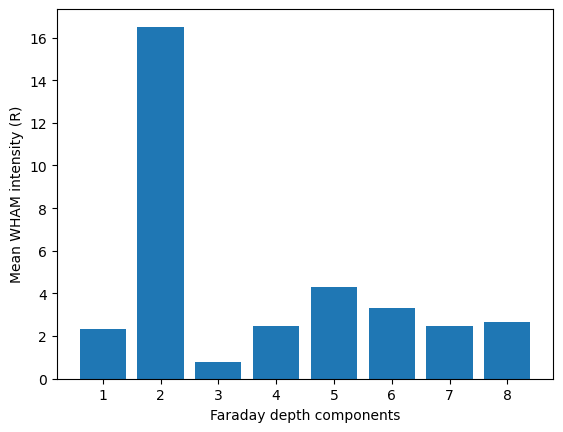

In [436]:
plt.bar(x, y)
plt.xlabel("Faraday depth components")
plt.ylabel("Mean WHAM intensity (R)")

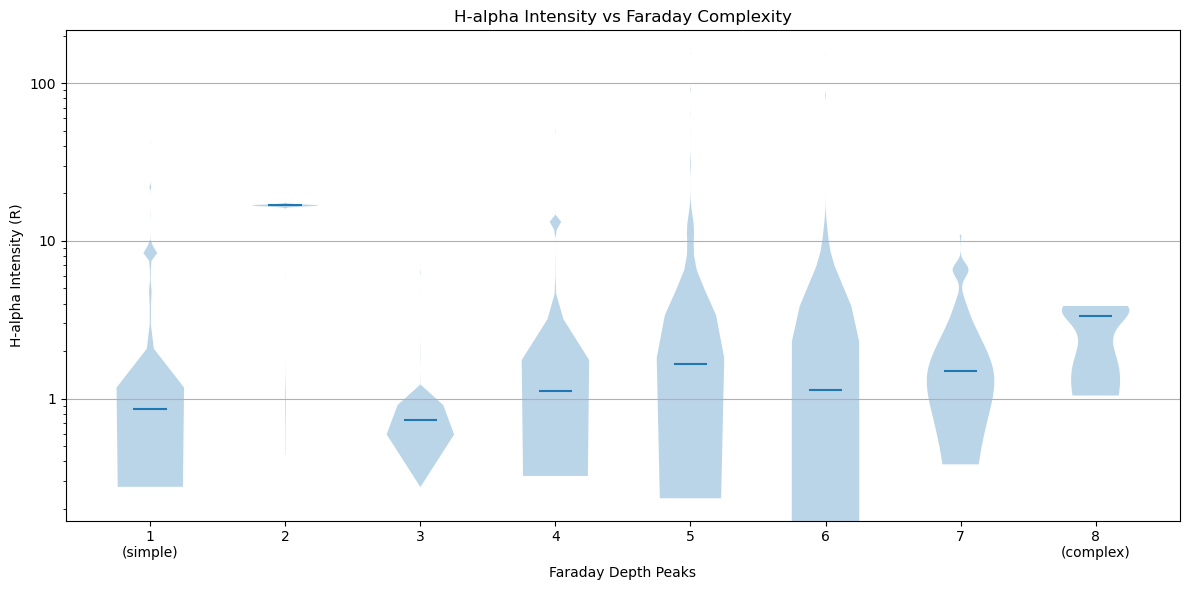

In [437]:
import matplotlib.ticker as ticker 

classLabels = ['1\n(simple)', '2', '3', '4', '5', '6', '7', '8\n(complex)']
classData = [compOneWhamSampled, compTwoWhamSampled, compThreeWhamSampled, compFourWhamSampled, 
             compFiveWhamSampled, compSixWhamSampled, compSevenWhamSampled, compEightWhamSampled]

fig, ax = plt.subplots(figsize=(12,6))
parts = ax.violinplot(classData, positions=range(1,9), showmedians=True, showextrema=False)

ax.set_xticks(range(1,9))
ax.set_xticklabels(classLabels)
ax.set_xlabel('Faraday Depth Peaks')
ax.set_ylabel('H-alpha Intensity (R)')
ax.set_title('H-alpha Intensity vs Faraday Complexity') #need a better title later 
ax.set_yscale('log')
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.grid(True, axis='y')
plt.tight_layout()


In [438]:
print(f"compTwoWhamSampled unique values: {len(np.unique(compTwoWhamSampled))}")
print(f"compTwoWhamSampled range: {compTwoWhamSampled.min():.2f} to {compTwoWhamSampled.max():.2f}")
print(f"compTwoWhamSampled median: {np.median(compTwoWhamSampled):.2f}")
print(f"compTwoWhamSampled std: {np.std(compTwoWhamSampled):.2f}")
print(f"compTwoWhamSampled shape: {compTwoWhamSampled.shape}")

compTwoWhamSampled unique values: 20
compTwoWhamSampled range: 0.44 to 21.58
compTwoWhamSampled median: 16.75
compTwoWhamSampled std: 1.96
compTwoWhamSampled shape: (60153,)


In [439]:
print(f"compTwoLoSCentroids shape: {compTwoLoSCentroids.shape}")
print(f"compTwoLoSCentroids unique rows: {len(np.unique(compTwoLoSCentroids, axis=0))}")
print(f"compTwoLoSCentroids sample:\n{compTwoLoSCentroids[:5]}")

compTwoLoSCentroids shape: (60153, 2)
compTwoLoSCentroids unique rows: 20
compTwoLoSCentroids sample:
[[144.43285   15.234663]
 [144.43285   15.234663]
 [144.43285   15.234663]
 [144.43285   15.234663]
 [144.43285   15.234663]]


In [440]:
print(wcs)
print(wcs.naxis)
print(f"compTwoNewLoS length: {len(compTwoNewLoS)}")
print(f"First region of compTwoNewLoS: {compTwoNewLoS[0][:3]}")
print(f"First region as array: {np.array(compTwoNewLoS[0], dtype=np.int32)[:3]}")

WCS Keywords

Number of WCS axes: 2
CTYPE : 'GLON-CAR' 'GLAT-CAR'
CUNIT : 'deg' 'deg'
CRVAL : 0.0 0.0
CRPIX : 360.5 180.5
PC1_1 PC1_2  : 1.0 0.0
PC2_1 PC2_2  : 0.0 1.0
CDELT : -0.5 0.5
NAXIS : 720  360
2
compTwoNewLoS length: 60153
First region of compTwoNewLoS: [(np.int64(69), np.int64(12)), (np.int64(75), np.int64(14)), (np.int64(74), np.int64(14))]
First region as array: [[69 12]
 [75 14]
 [74 14]]


In [443]:
testRegion = np.array(compTwoNewLoS[0], dtype=np.int32)
testSky = wcs.pixel_to_world(testRegion[:, 0], testRegion[:, 1])
testGal = testSky.galactic
print(f"Test l values: {testGal.l.deg[:5]}")
print(f"Test b values: {testGal.b.deg[:5]}")
print(f"Test mean l: {np.mean(testGal.l.deg):.4f}")
print(f"Test mean b: {np.mean(testGal.b.deg):.4f}")

Test l values: [145.25 142.25 142.75 143.25 141.75]
Test b values: [-83.75 -82.75 -82.75 -82.75 -83.25]
Test mean l: 144.4328
Test mean b: 15.2347
